In [8]:
import math

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [9]:
class Net(nn.Module):
    def __init__(self, layers=(1, 20, 1)):
        super().__init__()
        net = []
        for i in range(len(layers)-2):
            net.append(nn.Linear(layers[i], layers[i+1]))
            net.append(nn.Tanh())
        net.append(nn.Linear(layers[-2], layers[-1]))
        self.net = nn.Sequential(*net)
    def forward(self, x):
        return self.net(x)

Consider simple ODE:
$$
\begin{cases}
u'' = 2 \\
u(0) = \frac{1}{16} \\
u(1) = \frac{9}{16}
\end{cases}
$$
The solution of the system is $u(x) = (x - \frac{1}{4})^2$

In [34]:
def schedulerComparison(factor, patience):
    # --- Collocation points ---
    N_f = 50
    x_f = torch.rand(N_f, 1, requires_grad=True)
    u_exact = torch.pow(x_f - 1.0/4.0, 2).detach()

    # --- Boundary points --
    x_bc = torch.cat([torch.zeros(5, 1), torch.ones(5, 1)], dim=0)
    u_bc = torch.cat([torch.full((5, 1), 1.0/16.0), torch.full((5, 1), 9.0/16.0)], dim=0)
    net = Net((1, 20, 40, 20, 1))

    optimizer = optim.Adam(net.parameters(), lr=1e-3)

    if factor < 1:
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=factor,
            patience=patience
        )

    mse_errors = []
    l2_errors = []
    l2_relative_errors = []
    lrs = []

    for epoch in range(6001):
        optimizer.zero_grad()

        # ODE residual
        u_f = net(x_f)
        u_x = torch.autograd.grad(u_f.sum(), x_f, create_graph=True)[0]
        u_xx = torch.autograd.grad(u_x, x_f, torch.ones_like(u_x), create_graph=True)[0]

        loss_ode = torch.mean((u_xx - 2) ** 2)

        # Boundary loss
        u_bc_pred = net(x_bc)
        loss_bc = torch.mean((u_bc_pred - u_bc) ** 2)

        loss = loss_ode + 2 * loss_bc
        loss.backward()
        optimizer.step()
        if factor < 1:
            scheduler.step(loss.detach())

        # Compute errors ar current epoch
        l2_errors.append(torch.norm(u_f - u_exact).detach().item())
        l2_relative_errors.append(torch.norm(u_f - u_exact).detach().item() / torch.norm(u_exact).detach().item())
        mse_errors.append(torch.mean((u_f - u_exact) ** 2).detach().item())
        lrs.append(optimizer.param_groups[0]['lr'])

    return l2_errors, l2_relative_errors, mse_errors, lrs

In [37]:
def plotResults(factor, patience):
    l2_errors, l2_relative_errors, mse_errors, lrs = schedulerComparison(factor, patience)
    plt.figure(figsize=(12,8))

    plt.subplot(2,1,1)
    plt.semilogy(np.arange(0, 6001), l2_errors, label="L2 error change")
    plt.semilogy(np.arange(0, 6001), l2_relative_errors, label="Relative L2 error change")
    plt.semilogy(np.arange(0, 6001), mse_errors, label="Mean square error change")
    plt.legend()
    plt.title('Errors change')
    plt.subplot(2,1,2)
    plt.semilogy(np.arange(0, 6001), lrs, label="L2 error change")
    plt.title('Learning rate change')
    plt.show()
    print(f"Minimum mean square error: {min(mse_errors)}")
    print(f"Minimum l2 error: {min(l2_errors)}")
    print(f"Minimum relative l2 error: {min(l2_relative_errors)}")

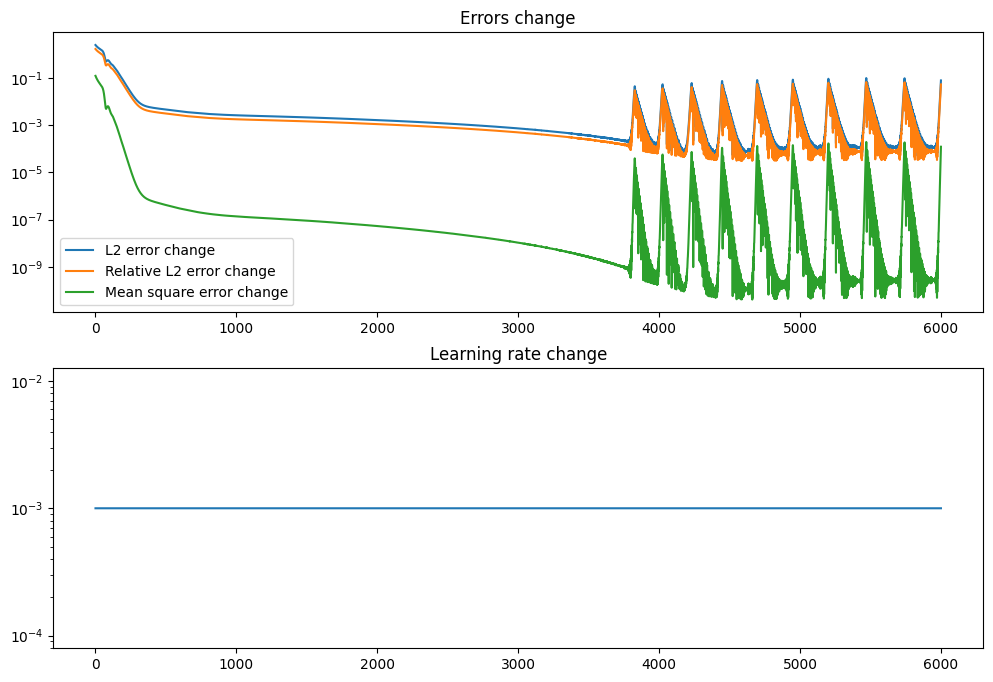

Minimum mean square error: 4.131528105744131e-11
Minimum l2 error: 4.5450677134795114e-05
Minimum relative l2 error: 3.080687464161547e-05


In [38]:
# the normal solution with no scheduler
plotResults(1, 500)  # technically no change in lr

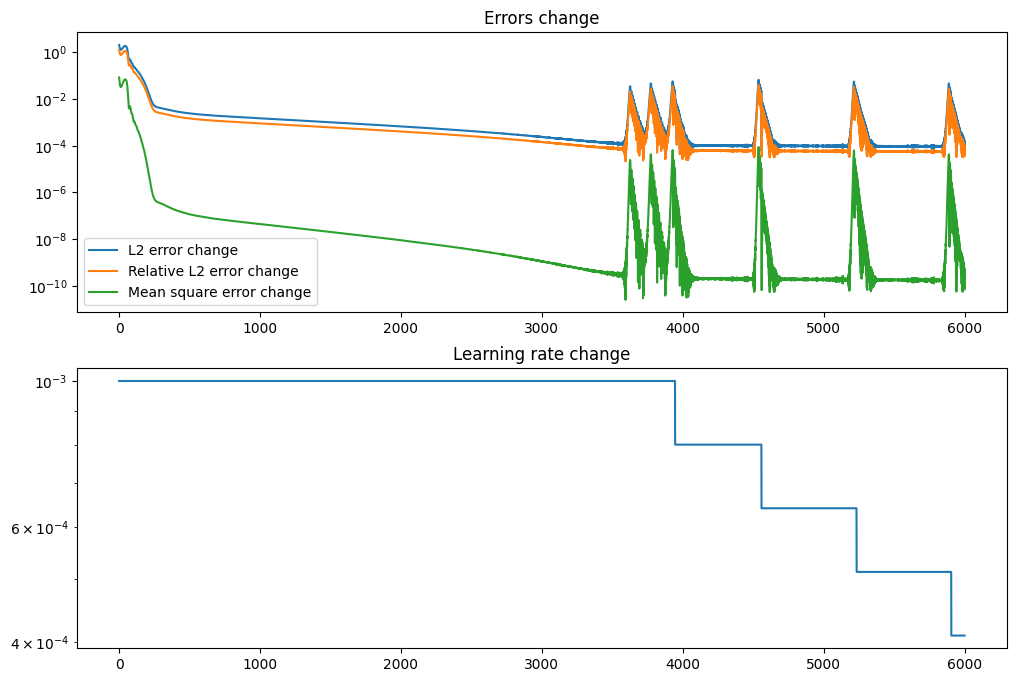

Minimum mean square error: 2.6102264447103174e-11
Minimum l2 error: 3.612635191529989e-05
Minimum relative l2 error: 2.189455657750689e-05


In [47]:
plotResults(0.8, 50)

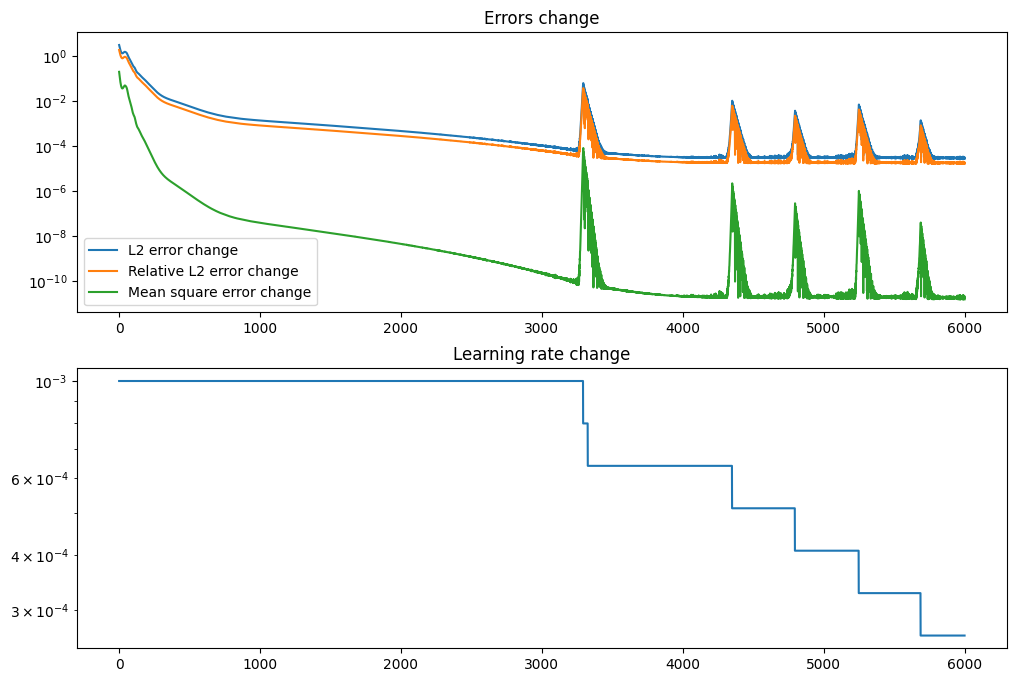

Minimum mean square error: 1.5662209376654523e-11
Minimum l2 error: 2.7984111511614174e-05
Minimum relative l2 error: 1.6828684189209047e-05


In [49]:
plotResults(0.8, 20)

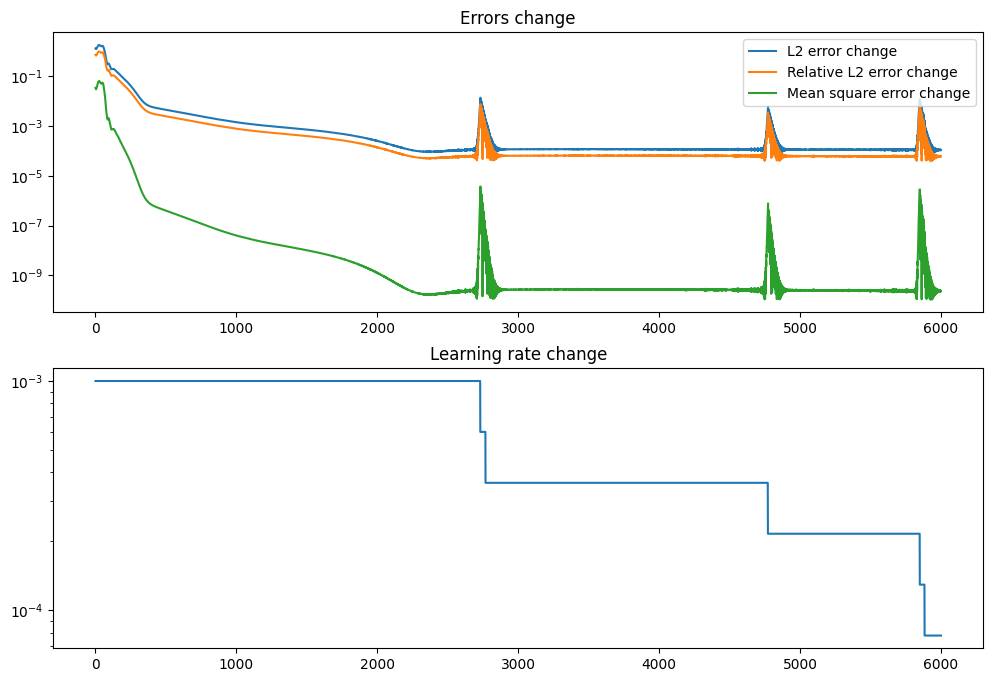

Minimum mean square error: 1.0695206525968004e-10
Minimum l2 error: 7.31273103156127e-05
Minimum relative l2 error: 4.0187539058809824e-05


In [50]:
plotResults(0.6, 20)

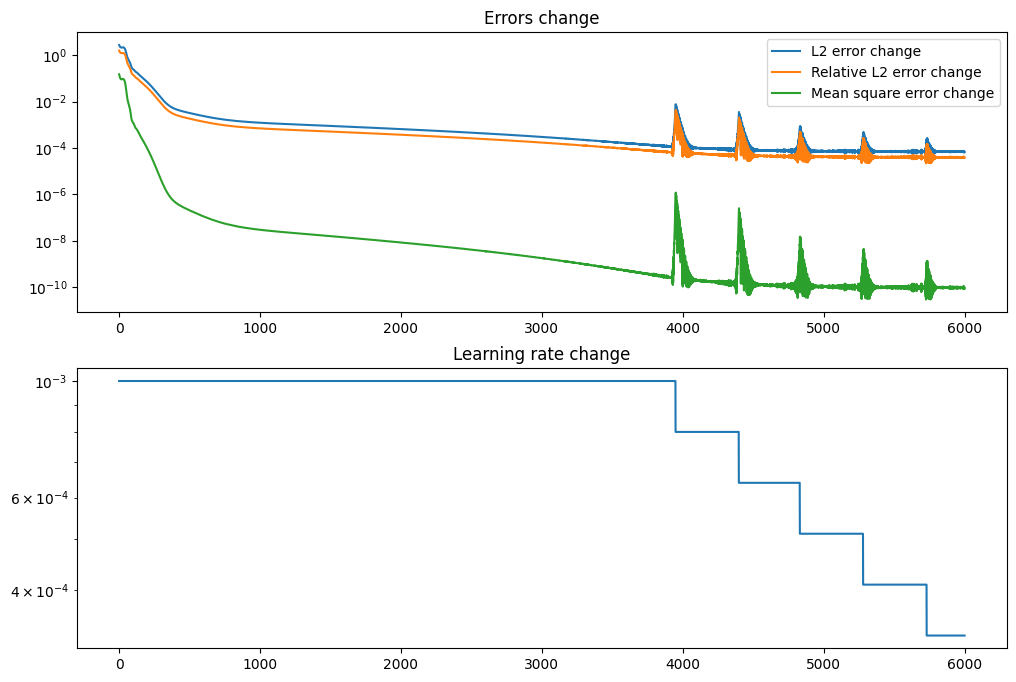

Minimum mean square error: 2.973878435175159e-11
Minimum l2 error: 3.8560850953217596e-05
Minimum relative l2 error: 2.2038371958659418e-05


In [51]:
plotResults(0.8, 10)